<a href="https://colab.research.google.com/github/Yuvraj6085/cnnpro/blob/main/MultiClassCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import requests

In [3]:

API_KEY = "52854155-0c17c21638c360c3d41a4aab2"   # Replace with your Pixabay API key
BASE_DIR = "dataset"               # Or use Google Drive path
CLASSES = ["cat", "dog","horse"]         # Classes for the dataset
IMAGES_PER_CLASS = 50              # Total images per class
TRAIN_RATIO = 0.8

In [4]:

for split in ["train", "test"]:
    for cls in CLASSES:
        path = os.path.join(BASE_DIR, split, cls)
        os.makedirs(path, exist_ok=True)

In [5]:
# Function to download images from Pixabay
def download_images(query, save_dir, count):
    print(f"Downloading {count} images for '{query}'...")
    per_page = 20
    downloaded = 0
    page = 1

    while downloaded < count:
        url = f"https://pixabay.com/api/?key={API_KEY}&q={query}&image_type=photo&per_page={per_page}&page={page}"
        response = requests.get(url)
        data = response.json()
        hits = data.get("hits", [])

        if not hits:
            print(f"No more images found for {query}")
            break

        for img in hits:
            if downloaded >= count:
                break
            img_url = img["largeImageURL"]
            try:
                img_data = requests.get(img_url).content
                with open(os.path.join(save_dir, f"{query}_{downloaded+1}.jpg"), "wb") as f:
                    f.write(img_data)
                downloaded += 1
            except Exception as e:
                print(f"Failed to download {img_url}: {e}")

        page += 1


In [6]:
for cls in CLASSES:
    train_count = int(IMAGES_PER_CLASS * TRAIN_RATIO)
    test_count = IMAGES_PER_CLASS - train_count

    train_dir = os.path.join(BASE_DIR, "train", cls)
    test_dir = os.path.join(BASE_DIR, "test", cls)

    download_images(cls, train_dir, train_count)
    download_images(cls, test_dir, test_count)

print("Download complete! Dataset is ready.")

Download complete! Dataset is ready.


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [9]:
train_set = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(224,224),   # MobileNetV2 expects 224x224 input
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 96 images belonging to 3 classes.


In [10]:
val_set = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 24 images belonging to 3 classes.


In [11]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model layers (do not train them)
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)  # 3 output classes

model = Model(inputs=base_model.input, outputs=predictions)

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
history = model.fit(
    train_set,
    epochs=10,
    validation_data=val_set
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.3451 - loss: 1.3866 - val_accuracy: 0.5417 - val_loss: 0.9236
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3776 - loss: 1.2186 - val_accuracy: 0.5417 - val_loss: 0.8795
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.4779 - loss: 1.0896 - val_accuracy: 0.6250 - val_loss: 0.8563
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4375 - loss: 1.0140 - val_accuracy: 0.6667 - val_loss: 0.7149
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.6315 - loss: 0.9291 - val_accuracy: 0.8333 - val_loss: 0.5945
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6094 - loss: 0.7776 - val_accuracy: 0.7500 - val_loss: 0.6147
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7135 - loss: 0.7337 - val_accuracy: 0.8750 - val_loss: 0.5453
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.6732 - loss: 0.7195 - val_accuracy: 0.8333 - val_loss: 0.5647
Epoch 9/10
3/3

In [17]:
loss, acc = model.evaluate(val_set)
print(f"✅ Validation Accuracy: {acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8750 - loss: 0.4846
✅ Validation Accuracy: 87.50%


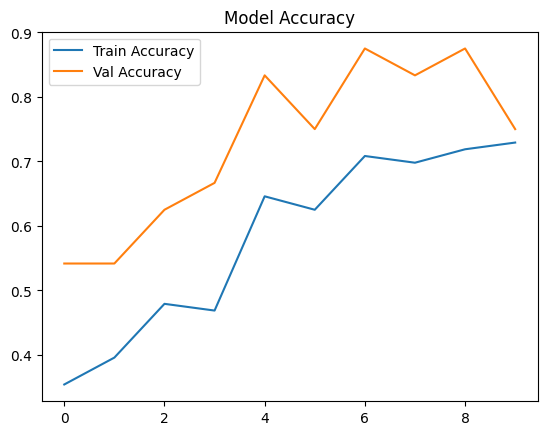

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Model Accuracy'); plt.show()


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Model Loss'); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


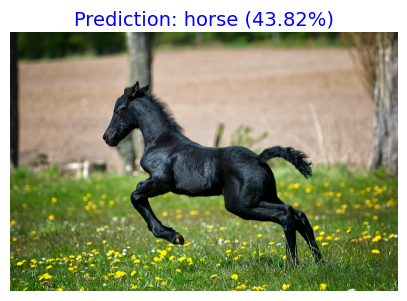

In [19]:
# =========================================
# Step 9: Single Image Prediction with Display
# =========================================
import cv2

img_path = '/content/horce.jpg'  # change path as needed

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

# Predict
pred = model.predict(x)
classes = list(train_set.class_indices.keys())
predicted_label = classes[np.argmax(pred)]
confidence = np.max(pred) * 100

# Show Image with Prediction
plt.figure(figsize=(5,5))
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=14, color='blue')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


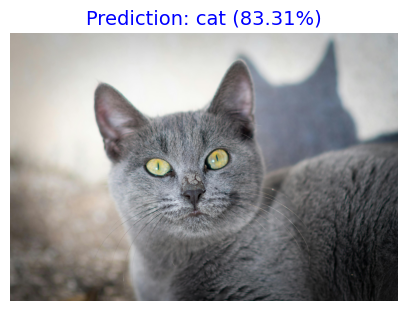

In [20]:
# =========================================
# Step 9: Single Image Prediction with Display
# =========================================
import cv2

img_path = '/content/d1.jpg'  # change path as needed

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

# Predict
pred = model.predict(x)
classes = list(train_set.class_indices.keys())
predicted_label = classes[np.argmax(pred)]
confidence = np.max(pred) * 100

# Show Image with Prediction
plt.figure(figsize=(5,5))
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=14, color='blue')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


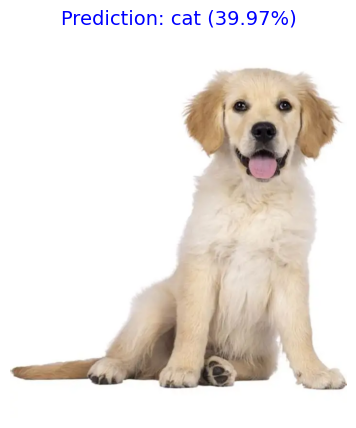

In [21]:
# =========================================
# Step 9: Single Image Prediction with Display
# =========================================
import cv2

img_path = '/content/d3.jpg'  # change path as needed

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

# Predict
pred = model.predict(x)
classes = list(train_set.class_indices.keys())
predicted_label = classes[np.argmax(pred)]
confidence = np.max(pred) * 100

# Show Image with Prediction
plt.figure(figsize=(5,5))
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=14, color='blue')
plt.axis('off')
plt.show()
